# Experiment 3 -- Definitive CL Benchmark (Shared Autonomy)

**PhD Project:** Collaboration Humain-Robot : Apprentissage incremental et adaptation comportementale
**Author:** Ameur Gargouri
**Notebook:** `05_definitive_benchmark.ipynb`

## Changes vs Experiment 01

| Change | Detail |
|--------|--------|
| **Data fix** | `mico_joint_6_pos` outliers clipped (3 corrupt samples in p109) |
| **SI dropped** | Degenerate on this task (identical MSE for all c values) |
| **A-GEM added** | Gradient projection method (Chaudhry et al., ICLR 2019) |
| **DER++ buffer** | 5000 -> **10000** (best from HP sweep) |
| **EWC lambda** | 5000 -> **10000** (best from HP sweep) |
| **Online EWC gamma** | 0.95 -> **0.99** (best from HP sweep) |

## Strategies (7)

| # | Strategy | Family | Key HP |
|---|----------|--------|--------|
| 1 | Naive Fine-Tune | Baseline (lower) | -- |
| 2 | Joint Training | Baseline (upper) | -- |
| 3 | EWC | Regularization | lambda=10000 |
| 4 | Online EWC | Regularization | lambda=10000, gamma=0.99 |
| 5 | LwF | Distillation | alpha=1.0 |
| 6 | DER++ | Replay | buffer=10000 |
| 7 | A-GEM | Gradient Projection | mem_per_task=256 |

---

In [1]:
import os, sys, abc, copy, json, logging, random, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Optional
from itertools import product

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(message)s')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} -- device: {DEVICE}')
if DEVICE == 'cuda': print(f'  GPU: {torch.cuda.get_device_name()}')

PROJECT_ROOT = "/home/g0amer/Desktop/thesis/phd_project/thesis_project"
HARMONIC_DIR = f'{PROJECT_ROOT}/data/processed/harmonic'
RESULTS_DIR  = f'{PROJECT_ROOT}/experiments/exp03_definitive_benchmark'
os.makedirs(RESULTS_DIR, exist_ok=True)

participants = sorted([d for d in os.listdir(HARMONIC_DIR)
                       if os.path.isdir(os.path.join(HARMONIC_DIR, d)) and d.startswith('p')])
print(f'Participants: {len(participants)} -> {participants}')
print(f'Results: {RESULTS_DIR}')

PyTorch 2.10.0+cu128 -- device: cuda
  GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Participants: 24 -> ['p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p106', 'p107', 'p108', 'p109', 'p110', 'p111', 'p112', 'p113', 'p114', 'p115', 'p116', 'p117', 'p118', 'p119', 'p120', 'p121', 'p122', 'p123']
Results: /home/g0amer/Desktop/thesis/phd_project/thesis_project/experiments/exp03_definitive_benchmark


In [2]:
# Metrics & Data Structures

@dataclass
class TaskResult:
    task_id: int; loss: float; mse: float; mae: float; r2: float; n_samples: int = 0
    per_dim_mse: list = field(default_factory=list)  # per-joint MSE

@dataclass
class ContinualMetrics:
    n_tasks: int = 0
    accuracy_matrix: list = field(default_factory=list)
    task_names: list = field(default_factory=list)
    per_dim_matrix: list = field(default_factory=list)  # per-joint accuracy matrix

    def record(self, trained_up_to, task_results):
        row = [r.mse for r in task_results]
        while len(self.accuracy_matrix) <= trained_up_to:
            self.accuracy_matrix.append([])
            self.per_dim_matrix.append([])
        self.accuracy_matrix[trained_up_to] = row
        self.per_dim_matrix[trained_up_to] = [r.per_dim_mse for r in task_results]

    @property
    def average_accuracy(self):
        if not self.accuracy_matrix: return float('nan')
        last = self.accuracy_matrix[-1]
        return float(np.mean(last)) if last else float('nan')

    @property
    def backward_transfer(self):
        T = len(self.accuracy_matrix)
        if T < 2: return 0.0
        bwt, cnt = 0.0, 0
        for j in range(T - 1):
            if j < len(self.accuracy_matrix[T-1]) and j < len(self.accuracy_matrix[j]):
                bwt += self.accuracy_matrix[T-1][j] - self.accuracy_matrix[j][j]; cnt += 1
        return bwt / cnt if cnt > 0 else 0.0

    @property
    def forward_transfer(self):
        T = len(self.accuracy_matrix)
        if T < 2: return 0.0
        fwt, cnt = 0.0, 0
        for j in range(1, T):
            if j < len(self.accuracy_matrix[j-1]) and j < len(self.accuracy_matrix[j]):
                fwt += self.accuracy_matrix[j-1][j] - self.accuracy_matrix[j][j]; cnt += 1
        return fwt / cnt if cnt > 0 else 0.0

    def summary_dict(self):
        return {'n_tasks': len(self.accuracy_matrix), 'average_mse': self.average_accuracy,
                'backward_transfer': self.backward_transfer, 'forward_transfer': self.forward_transfer,
                'accuracy_matrix': self.accuracy_matrix, 'task_names': self.task_names,
                'per_dim_matrix': self.per_dim_matrix}

@dataclass
class TaskData:
    task_id: int; participant_id: str
    obs_train: torch.Tensor; act_train: torch.Tensor
    obs_val: torch.Tensor; act_val: torch.Tensor
    obs_test: torch.Tensor; act_test: torch.Tensor

    @property
    def n_train(self): return self.obs_train.shape[0]
    @property
    def n_val(self): return self.obs_val.shape[0]
    @property
    def n_test(self): return self.obs_test.shape[0]
    def train_loader(self, bs=256):
        return DataLoader(TensorDataset(self.obs_train, self.act_train), batch_size=bs, shuffle=True)
    def val_loader(self, bs=512):
        return DataLoader(TensorDataset(self.obs_val, self.act_val), batch_size=bs)
    def test_loader(self, bs=512):
        return DataLoader(TensorDataset(self.obs_test, self.act_test), batch_size=bs)

print('Metrics & TaskData defined')

Metrics & TaskData defined


In [3]:
# Model & CL Strategies (SI dropped, A-GEM added)

class MLPPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(256,256), dropout=0.1):
        super().__init__()
        layers = []
        d = obs_dim
        for h in hidden:
            layers += [nn.Linear(d,h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers.append(nn.Linear(d, act_dim))
        self.net = nn.Sequential(*layers)
        self.obs_dim, self.act_dim = obs_dim, act_dim
    def forward(self, x): return self.net(x)

class ContinualLearner(abc.ABC):
    def __init__(self, model, lr=1e-3, weight_decay=0., device='cpu'):
        self.model = model.to(device); self.device = device; self.lr = lr
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        self._current_task = -1
    @abc.abstractmethod
    def on_task_start(self, task_id, train_loader): ...
    @abc.abstractmethod
    def compute_loss(self, obs, act, task_id): ...
    @abc.abstractmethod
    def on_task_end(self, task_id, train_loader): ...

    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        self.model.train()
        best_val, best_state, no_improve = float('inf'), None, 0
        history = {'train_loss': [], 'val_loss': []}
        for epoch in range(epochs):
            eloss, nb = 0., 0
            for batch in train_loader:
                obs, act = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                loss = self.compute_loss(obs, act, task_id)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                eloss += loss.item(); nb += 1
            avg = eloss / max(nb, 1)
            history['train_loss'].append(avg)
            if val_loader is not None:
                vl = self._eval_loss(val_loader)
                history['val_loss'].append(vl)
                if vl < best_val:
                    best_val = vl; best_state = copy.deepcopy(self.model.state_dict()); no_improve = 0
                else: no_improve += 1
                if no_improve >= patience: break
        if best_state is not None: self.model.load_state_dict(best_state)
        self.on_task_end(task_id, train_loader)
        return history

    def _eval_loss(self, loader):
        self.model.eval()
        tot, n = 0., 0
        with torch.no_grad():
            for b in loader:
                o, a = b[0].to(self.device), b[1].to(self.device)
                tot += F.mse_loss(self.model(o), a).item() * o.size(0); n += o.size(0)
        self.model.train()
        return tot / max(n, 1)

    def evaluate_task(self, test_loader, task_id):
        self.model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for b in test_loader:
                o, a = b[0].to(self.device), b[1].to(self.device)
                preds.append(self.model(o).cpu()); tgts.append(a.cpu())
        p, t = torch.cat(preds), torch.cat(tgts)
        mse = F.mse_loss(p, t).item()
        mae = (p - t).abs().mean().item()
        ss_res = ((t - p)**2).sum().item()
        ss_tot = ((t - t.mean(0))**2).sum().item()
        r2 = 1 - ss_res / max(ss_tot, 1e-8)
        # Per-dimension (per-joint) MSE
        per_dim = ((p - t)**2).mean(0).tolist()
        self.model.train()
        return TaskResult(task_id, mse, mse, mae, r2, len(t), per_dim)

# --- 1. Naive Fine-Tune ---
class NaiveFineTune(ContinualLearner):
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, t): return F.mse_loss(self.model(obs), act)
    def on_task_end(self, t, l): pass

# --- 2. Joint Training ---
class JointTraining(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu'):
        super().__init__(model, lr=lr, device=device)
        self._datasets = {}; self._init_state = copy.deepcopy(model.state_dict())
    def on_task_start(self, task_id, train_loader):
        all_o, all_a = [], []
        for b in train_loader: all_o.append(b[0]); all_a.append(b[1])
        self._datasets[task_id] = TensorDataset(torch.cat(all_o), torch.cat(all_a))
        self.model.load_state_dict(copy.deepcopy(self._init_state))
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
    def compute_loss(self, obs, act, t): return F.mse_loss(self.model(obs), act)
    def on_task_end(self, t, l): pass
    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        joint_ds = ConcatDataset(list(self._datasets.values()))
        bs = train_loader.batch_size if hasattr(train_loader, 'batch_size') else 256
        joint_loader = DataLoader(joint_ds, batch_size=bs, shuffle=True)
        self.model.train()
        return super().train_task(task_id, joint_loader, val_loader, epochs, patience, verbose)

# --- 3. EWC (tuned: lambda=10000) ---
class EWC(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', ewc_lambda=10000., fisher_samples=1000,
                 online=False, gamma=0.99):
        super().__init__(model, lr=lr, device=device)
        self.ewc_lambda = ewc_lambda; self.fisher_samples = fisher_samples
        self.online = online; self.gamma = gamma
        self._fishers = []; self._opt_params = []
        self._run_fisher = None; self._run_params = None
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, task_id):
        loss = F.mse_loss(self.model(obs), act)
        if task_id == 0: return loss
        return loss + self._penalty()
    def on_task_end(self, task_id, train_loader):
        fisher = self._compute_fisher(train_loader)
        if self.online:
            if self._run_fisher is None: self._run_fisher = fisher
            else:
                for n in self._run_fisher:
                    self._run_fisher[n] = self.gamma * self._run_fisher[n] + fisher[n]
            self._run_params = {n: p.clone().detach() for n, p in self.model.named_parameters() if p.requires_grad}
        else:
            self._fishers.append(fisher)
            self._opt_params.append({n: p.clone().detach() for n, p in self.model.named_parameters() if p.requires_grad})
    def _compute_fisher(self, loader):
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters() if p.requires_grad}
        self.model.eval(); ns = 0
        for b in loader:
            o, a = b[0].to(self.device), b[1].to(self.device)
            self.model.zero_grad()
            F.mse_loss(self.model(o), a).backward()
            for n, p in self.model.named_parameters():
                if p.requires_grad and p.grad is not None:
                    fisher[n] += p.grad.data.pow(2) * o.size(0)
            ns += o.size(0)
            if ns >= self.fisher_samples: break
        for n in fisher: fisher[n] /= max(ns, 1)
        self.model.train()
        return fisher
    def _penalty(self):
        pen = torch.tensor(0., device=self.device)
        if self.online and self._run_fisher is not None:
            for n, p in self.model.named_parameters():
                if n in self._run_fisher:
                    pen += (self._run_fisher[n] * (p - self._run_params[n]).pow(2)).sum()
        else:
            for fi, op in zip(self._fishers, self._opt_params):
                for n, p in self.model.named_parameters():
                    if n in fi: pen += (fi[n] * (p - op[n]).pow(2)).sum()
        return (self.ewc_lambda / 2.) * pen

# --- 4. LwF ---
class LwF(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', lwf_alpha=1.0):
        super().__init__(model, lr=lr, device=device)
        self.lwf_alpha = lwf_alpha; self._teacher = None
    def on_task_start(self, task_id, train_loader):
        if task_id > 0:
            self._teacher = copy.deepcopy(self.model); self._teacher.eval()
            for p in self._teacher.parameters(): p.requires_grad = False
        else: self._teacher = None
    def compute_loss(self, obs, act, task_id):
        pred = self.model(obs); loss = F.mse_loss(pred, act)
        if self._teacher is not None and task_id > 0:
            with torch.no_grad(): teacher_pred = self._teacher(obs)
            loss = loss + self.lwf_alpha * F.mse_loss(pred, teacher_pred)
        return loss
    def on_task_end(self, t, l): pass

# --- 5. DER++ (tuned: buffer=10000) ---
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity; self.obs, self.act, self.logits = [], [], []; self._n = 0
    def __len__(self): return len(self.obs)
    def add(self, obs, act, logits):
        for i in range(obs.size(0)):
            self._n += 1
            if len(self.obs) < self.capacity:
                self.obs.append(obs[i].cpu()); self.act.append(act[i].cpu()); self.logits.append(logits[i].cpu())
            else:
                j = random.randint(0, self._n - 1)
                if j < self.capacity:
                    self.obs[j] = obs[i].cpu(); self.act[j] = act[i].cpu(); self.logits[j] = logits[i].cpu()
    def sample(self, n):
        n = min(n, len(self.obs)); idx = random.sample(range(len(self.obs)), n)
        return (torch.stack([self.obs[i] for i in idx]),
                torch.stack([self.act[i] for i in idx]),
                torch.stack([self.logits[i] for i in idx]))

class DERPlusPlus(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', buffer_size=10000, alpha=0.5, beta=0.5):
        super().__init__(model, lr=lr, device=device)
        self.buffer = ReplayBuffer(buffer_size); self.alpha = alpha; self.beta = beta
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, task_id):
        pred = self.model(obs); loss = F.mse_loss(pred, act)
        with torch.no_grad(): logits = self.model(obs).detach()
        self.buffer.add(obs.detach(), act.detach(), logits)
        if len(self.buffer) > 0 and task_id > 0:
            bo, ba, bl = self.buffer.sample(max(1, obs.size(0)))
            bo, ba, bl = bo.to(self.device), ba.to(self.device), bl.to(self.device)
            bp = self.model(bo)
            loss = loss + self.alpha * F.mse_loss(bp, bl) + self.beta * F.mse_loss(bp, ba)
        return loss
    def on_task_end(self, t, l): pass

# --- 6. A-GEM (Averaged Gradient Episodic Memory) ---
# Chaudhry et al., ICLR 2019
# Stores episodic memory per task. At each step, if the current gradient
# increases loss on stored memories, project it to the feasible cone.
class EpisodicMemory:
    def __init__(self, capacity_per_task=256):
        self.capacity = capacity_per_task
        self.memories = {}  # task_id -> (obs, act)

    def store(self, task_id, train_loader):
        all_o, all_a = [], []
        for b in train_loader:
            all_o.append(b[0]); all_a.append(b[1])
        obs = torch.cat(all_o); act = torch.cat(all_a)
        # Reservoir sample to capacity
        if len(obs) > self.capacity:
            idx = torch.randperm(len(obs))[:self.capacity]
            obs, act = obs[idx], act[idx]
        self.memories[task_id] = (obs, act)

    def get_batch(self):
        # Return a combined batch from all stored tasks
        if not self.memories:
            return None, None
        all_o = [v[0] for v in self.memories.values()]
        all_a = [v[1] for v in self.memories.values()]
        return torch.cat(all_o), torch.cat(all_a)

class AGEM(ContinualLearner):
    # A-GEM: project gradient if it violates episodic memory constraint
    def __init__(self, model, lr=1e-3, device='cpu', mem_per_task=256):
        super().__init__(model, lr=lr, device=device)
        self.memory = EpisodicMemory(mem_per_task)

    def on_task_start(self, task_id, train_loader): pass

    def compute_loss(self, obs, act, task_id):
        return F.mse_loss(self.model(obs), act)

    def on_task_end(self, task_id, train_loader):
        self.memory.store(task_id, train_loader)

    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        self.model.train()
        best_val, best_state, no_improve = float('inf'), None, 0
        history = {'train_loss': [], 'val_loss': []}

        for epoch in range(epochs):
            eloss, nb = 0., 0
            for batch in train_loader:
                obs, act = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                loss = self.compute_loss(obs, act, task_id)
                loss.backward()

                # A-GEM gradient projection
                if task_id > 0:
                    # Save current gradient
                    g = torch.cat([p.grad.data.view(-1) for p in self.model.parameters() if p.grad is not None])

                    # Compute reference gradient on episodic memory
                    mem_o, mem_a = self.memory.get_batch()
                    if mem_o is not None:
                        mem_o, mem_a = mem_o.to(self.device), mem_a.to(self.device)
                        self.optimizer.zero_grad()
                        ref_loss = F.mse_loss(self.model(mem_o), mem_a)
                        ref_loss.backward()
                        g_ref = torch.cat([p.grad.data.view(-1) for p in self.model.parameters() if p.grad is not None])

                        # Project if violation: g . g_ref < 0
                        dot = (g * g_ref).sum()
                        if dot < 0:
                            g = g - (dot / (g_ref.norm()**2 + 1e-8)) * g_ref

                        # Write projected gradient back
                        offset = 0
                        for p in self.model.parameters():
                            if p.grad is not None:
                                numel = p.grad.numel()
                                p.grad.data.copy_(g[offset:offset+numel].view_as(p.grad))
                                offset += numel

                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                eloss += loss.item(); nb += 1

            avg = eloss / max(nb, 1)
            history['train_loss'].append(avg)
            if val_loader is not None:
                vl = self._eval_loss(val_loader)
                history['val_loss'].append(vl)
                if vl < best_val:
                    best_val = vl; best_state = copy.deepcopy(self.model.state_dict()); no_improve = 0
                else: no_improve += 1
                if no_improve >= patience: break
        if best_state is not None: self.model.load_state_dict(best_state)
        self.on_task_end(task_id, train_loader)
        return history

print('Strategies defined: Naive, Joint, EWC, Online EWC, LwF, DER++, A-GEM')
print('  SI dropped (degenerate on this task)')
print('  A-GEM added (Chaudhry et al., ICLR 2019)')

Strategies defined: Naive, Joint, EWC, Online EWC, LwF, DER++, A-GEM
  SI dropped (degenerate on this task)
  A-GEM added (Chaudhry et al., ICLR 2019)


In [4]:
# Data Loading -- with outlier fix for mico_joint_6_pos

JOY_COLS   = ['axes_x', 'axes_y', 'axes_z']
JPOS_COLS  = [f'mico_joint_{i}_pos' for i in range(1, 7)]
EE_COLS    = ['mico_end_effector_x', 'mico_end_effector_y', 'mico_end_effector_z']
JVEL_COLS  = [f'mico_joint_{i}_vel' for i in range(1, 7)]
OBS_COLS   = JOY_COLS + JPOS_COLS + EE_COLS   # 12 input features
TARGET_COLS = JVEL_COLS                         # 6 output features
JOINT_POS_CLIP = 50.0

def load_participant(processed_dir, participant, val_ratio=0.15, seed=42):
    pdir = Path(processed_dir) / participant
    assert pdir.exists(), f'Not found: {pdir}'

    all_obs, all_tgt = [], []
    for trial_dir in sorted(pdir.iterdir()):
        if not trial_dir.is_dir():
            continue
        joy_path  = trial_dir / 'ada_joy.parquet'
        jpos_path = trial_dir / 'joint_positions.parquet'
        rpos_path = trial_dir / 'robot_position.parquet'
        if not all(p.exists() for p in [joy_path, jpos_path, rpos_path]):
            continue
        df_joy  = pd.read_parquet(joy_path)
        df_jpos = pd.read_parquet(jpos_path)
        df_rpos = pd.read_parquet(rpos_path)
        n = min(len(df_joy), len(df_jpos), len(df_rpos))
        if n < 10:
            continue

        # Outlier fix: clip extreme joint position values
        for col_name in JPOS_COLS:
            if col_name in df_jpos.columns:
                mask = df_jpos[col_name].abs() > JOINT_POS_CLIP
                if mask.any():
                    median_val = df_jpos.loc[~mask, col_name].median()
                    df_jpos.loc[mask, col_name] = median_val

        obs_parts = []
        for cols, df in [(JOY_COLS, df_joy), (JPOS_COLS, df_jpos), (EE_COLS, df_rpos)]:
            available = [c for c in cols if c in df.columns]
            if len(available) != len(cols):
                break
            obs_parts.append(df[available].values[:n])
        else:
            tgt_available = [c for c in JVEL_COLS if c in df_jpos.columns]
            if len(tgt_available) != len(JVEL_COLS):
                continue
            tgt_arr = df_jpos[tgt_available].values[:n]
            obs_arr = np.concatenate(obs_parts, axis=1)
            valid = ~(np.isnan(obs_arr).any(1) | np.isnan(tgt_arr).any(1))
            obs_arr, tgt_arr = obs_arr[valid], tgt_arr[valid]
            if len(obs_arr) > 0:
                all_obs.append(obs_arr)
                all_tgt.append(tgt_arr)
            continue
        continue

    assert all_obs, f'No data for {participant}'
    obs = np.nan_to_num(np.concatenate(all_obs).astype(np.float32))
    tgt = np.nan_to_num(np.concatenate(all_tgt).astype(np.float32))

    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(obs))
    nv = int(len(obs) * val_ratio)
    nt = nv
    obs_t, tgt_t = torch.from_numpy(obs), torch.from_numpy(tgt)
    return (obs_t[idx[nt+nv:]], tgt_t[idx[nt+nv:]],
            obs_t[idx[nt:nt+nv]], tgt_t[idx[nt:nt+nv]],
            obs_t[idx[:nt]],     tgt_t[idx[:nt]])

print(f'load_participant defined (outlier clipping at |val|>{JOINT_POS_CLIP})')
print(f'  Obs ({len(OBS_COLS)}): {OBS_COLS}')
print(f'  Tgt ({len(TARGET_COLS)}): {TARGET_COLS}')

load_participant defined (outlier clipping at |val|>50.0)
  Obs (12): ['axes_x', 'axes_y', 'axes_z', 'mico_joint_1_pos', 'mico_joint_2_pos', 'mico_joint_3_pos', 'mico_joint_4_pos', 'mico_joint_5_pos', 'mico_joint_6_pos', 'mico_end_effector_x', 'mico_end_effector_y', 'mico_end_effector_z']
  Tgt (6): ['mico_joint_1_vel', 'mico_joint_2_vel', 'mico_joint_3_vel', 'mico_joint_4_vel', 'mico_joint_5_vel', 'mico_joint_6_vel']


In [5]:
# Build task sequence (10 participants) + normalize

N_TASKS = min(len(participants), 10)
SEED = 42

task_pids = participants[:N_TASKS]
print(f'Building {N_TASKS} tasks from: {task_pids}')

tasks = []
for tid, pid in enumerate(task_pids):
    data = load_participant(HARMONIC_DIR, pid, seed=SEED)
    td = TaskData(tid, pid, *data)
    tasks.append(td)
    print(f'  Task {tid:2d} ({pid}): train={td.n_train:5d}  val={td.n_val:4d}  test={td.n_test:4d}')

obs_dim = tasks[0].obs_train.shape[1]
act_dim = tasks[0].act_train.shape[1]

# Global z-score normalization
all_obs_train = torch.cat([t.obs_train for t in tasks])
all_act_train = torch.cat([t.act_train for t in tasks])
obs_mean = all_obs_train.mean(0)
obs_std  = all_obs_train.std(0).clamp(min=1e-6)
act_mean = all_act_train.mean(0)
act_std  = all_act_train.std(0).clamp(min=1e-6)

for t in tasks:
    t.obs_train = (t.obs_train - obs_mean) / obs_std
    t.obs_val   = (t.obs_val   - obs_mean) / obs_std
    t.obs_test  = (t.obs_test  - obs_mean) / obs_std
    t.act_train = (t.act_train - act_mean) / act_std
    t.act_val   = (t.act_val   - act_mean) / act_std
    t.act_test  = (t.act_test  - act_mean) / act_std

del all_obs_train, all_act_train

print(f'\nobs_dim={obs_dim}, act_dim={act_dim}, n_tasks={len(tasks)}')
assert obs_std.max() < 100, f'Anomaly in obs_std: {obs_std}'
print('No anomalous normalization stats')

Building 10 tasks from: ['p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p106', 'p107', 'p108', 'p109']
  Task  0 (p100): train=21274  val=4558  test=4558
  Task  1 (p101): train=26797  val=5742  test=5742
  Task  2 (p102): train=33573  val=7194  test=7194
  Task  3 (p103): train=16945  val=3631  test=3631
  Task  4 (p104): train=17868  val=3828  test=3828
  Task  5 (p105): train=11065  val=2371  test=2371
  Task  6 (p106): train=31734  val=6800  test=6800
  Task  7 (p107): train=14412  val=3087  test=3087
  Task  8 (p108): train=10253  val=2196  test=2196
  Task  9 (p109): train=21081  val=4516  test=4516

obs_dim=12, act_dim=6, n_tasks=10
No anomalous normalization stats


In [6]:
# Benchmark Runner & Config

HIDDEN   = (256, 256)
LR       = 1e-3
DROPOUT  = 0.1
EPOCHS   = 50
PATIENCE = 10
BS       = 256

# Tuned HPs from experiment 02
EWC_LAMBDA    = 10000.0
EWC_FISHER_N  = 1000
OEWC_GAMMA    = 0.99
LWF_ALPHA     = 1.0
DER_BUFFER    = 10000
DER_ALPHA     = 0.5
DER_BETA      = 0.5
AGEM_MEM      = 256

def make_model():
    return MLPPolicy(obs_dim, act_dim, HIDDEN, DROPOUT)

def run_benchmark(name, learner, task_list, epochs=EPOCHS, patience=PATIENCE, bs=BS, verbose=True):
    metrics = ContinualMetrics(n_tasks=len(task_list),
                               task_names=[t.participant_id for t in task_list])
    histories = []
    t0 = time.time()
    for task in task_list:
        if verbose:
            print(f'\n{"="*55}')
            print(f'[{name}] Task {task.task_id} ({task.participant_id}) -- '
                  f'train={task.n_train}, val={task.n_val}')
            print(f'{"="*55}')
        h = learner.train_task(task.task_id, task.train_loader(bs),
                              task.val_loader(bs*2), epochs=epochs,
                              patience=patience, verbose=verbose)
        histories.append(h)
        results = []
        for et in task_list:
            tr = learner.evaluate_task(et.test_loader(bs*2), et.task_id)
            results.append(tr)
            if verbose and et.task_id <= task.task_id:
                tag = 'CUR' if et.task_id == task.task_id else 'OLD'
                print(f'  [{tag}] Task {et.task_id} ({et.participant_id}): '
                      f'MSE={tr.mse:.6f}  MAE={tr.mae:.4f}  R2={tr.r2:.4f}')
        metrics.record(task.task_id, results)
    elapsed = time.time() - t0
    if verbose:
        print(f'\n[{name}] Done in {elapsed:.1f}s')
        print(f'  Avg MSE: {metrics.average_accuracy:.6f}  BWT: {metrics.backward_transfer:+.6f}')
    return {'name': name, 'metrics': metrics, 'time': elapsed, 'histories': histories}

config = {
    'experiment': 'definitive_benchmark',
    'changes': 'outlier_fix + tuned_HPs + SI_dropped + AGEM_added',
    'input_features': OBS_COLS, 'target_features': TARGET_COLS,
    'hidden': list(HIDDEN), 'lr': LR, 'dropout': DROPOUT,
    'epochs': EPOCHS, 'patience': PATIENCE, 'batch_size': BS,
    'ewc_lambda': EWC_LAMBDA, 'ewc_fisher_n': EWC_FISHER_N,
    'oewc_gamma': OEWC_GAMMA, 'lwf_alpha': LWF_ALPHA,
    'der_buffer': DER_BUFFER, 'der_alpha': DER_ALPHA, 'der_beta': DER_BETA,
    'agem_mem_per_task': AGEM_MEM,
    'obs_dim': obs_dim, 'act_dim': act_dim, 'n_tasks': len(tasks),
    'seed': SEED, 'device': DEVICE,
}
with open(f'{RESULTS_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Config saved. Ready to run.')
print(json.dumps(config, indent=2))

Config saved. Ready to run.
{
  "experiment": "definitive_benchmark",
  "changes": "outlier_fix + tuned_HPs + SI_dropped + AGEM_added",
  "input_features": [
    "axes_x",
    "axes_y",
    "axes_z",
    "mico_joint_1_pos",
    "mico_joint_2_pos",
    "mico_joint_3_pos",
    "mico_joint_4_pos",
    "mico_joint_5_pos",
    "mico_joint_6_pos",
    "mico_end_effector_x",
    "mico_end_effector_y",
    "mico_end_effector_z"
  ],
  "target_features": [
    "mico_joint_1_vel",
    "mico_joint_2_vel",
    "mico_joint_3_vel",
    "mico_joint_4_vel",
    "mico_joint_5_vel",
    "mico_joint_6_vel"
  ],
  "hidden": [
    256,
    256
  ],
  "lr": 0.001,
  "dropout": 0.1,
  "epochs": 50,
  "patience": 10,
  "batch_size": 256,
  "ewc_lambda": 10000.0,
  "ewc_fisher_n": 1000,
  "oewc_gamma": 0.99,
  "lwf_alpha": 1.0,
  "der_buffer": 10000,
  "der_alpha": 0.5,
  "der_beta": 0.5,
  "agem_mem_per_task": 256,
  "obs_dim": 12,
  "act_dim": 6,
  "n_tasks": 10,
  "seed": 42,
  "device": "cuda"
}


In [7]:
# Helper to run + save

def run_and_save(name, learner):
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    result = run_benchmark(name, learner, tasks, epochs=EPOCHS, patience=PATIENCE, bs=BS, verbose=True)
    all_results[name] = result
    fname = name.lower().replace(' ', '_').replace('+', 'p').replace('-', '')
    with open(f'{RESULTS_DIR}/{fname}_results.json', 'w') as f:
        json.dump(result['metrics'].summary_dict(), f, indent=2, default=str)
    return result

all_results = {}
print(f'Ready -- obs_dim={obs_dim}, act_dim={act_dim}, n_tasks={len(tasks)}')

Ready -- obs_dim=12, act_dim=6, n_tasks=10


---
## Run All 7 Strategies

In [8]:
# 1. Naive Fine-Tune (lower bound)
res_naive = run_and_save('Naive Fine-Tune', NaiveFineTune(make_model(), lr=LR, device=DEVICE))


[Naive Fine-Tune] Task 0 (p100) -- train=21274, val=4558
  [CUR] Task 0 (p100): MSE=0.209833  MAE=0.2451  R2=0.7475

[Naive Fine-Tune] Task 1 (p101) -- train=26797, val=5742
  [OLD] Task 0 (p100): MSE=1.019168  MAE=0.6242  R2=-0.2262
  [CUR] Task 1 (p101): MSE=0.245043  MAE=0.2668  R2=0.7808

[Naive Fine-Tune] Task 2 (p102) -- train=33573, val=7194
  [OLD] Task 0 (p100): MSE=0.863780  MAE=0.4954  R2=-0.0392
  [OLD] Task 1 (p101): MSE=0.834982  MAE=0.5198  R2=0.2529
  [CUR] Task 2 (p102): MSE=0.071041  MAE=0.1350  R2=0.8807

[Naive Fine-Tune] Task 3 (p103) -- train=16945, val=3631
  [OLD] Task 0 (p100): MSE=0.991006  MAE=0.5781  R2=-0.1923
  [OLD] Task 1 (p101): MSE=1.022840  MAE=0.5522  R2=0.0848
  [OLD] Task 2 (p102): MSE=0.526733  MAE=0.4342  R2=0.1153
  [CUR] Task 3 (p103): MSE=0.267054  MAE=0.2652  R2=0.7750

[Naive Fine-Tune] Task 4 (p104) -- train=17868, val=3828
  [OLD] Task 0 (p100): MSE=0.934402  MAE=0.6192  R2=-0.1242
  [OLD] Task 1 (p101): MSE=1.153775  MAE=0.6773  R2=-0.03

In [9]:
# 2. Joint Training (upper bound)
res_joint = run_and_save('Joint Training', JointTraining(make_model(), lr=LR, device=DEVICE))


[Joint Training] Task 0 (p100) -- train=21274, val=4558
  [CUR] Task 0 (p100): MSE=0.206254  MAE=0.2412  R2=0.7519

[Joint Training] Task 1 (p101) -- train=26797, val=5742
  [OLD] Task 0 (p100): MSE=0.225419  MAE=0.2550  R2=0.7288
  [CUR] Task 1 (p101): MSE=0.258100  MAE=0.2786  R2=0.7691

[Joint Training] Task 2 (p102) -- train=33573, val=7194
  [OLD] Task 0 (p100): MSE=0.198763  MAE=0.2323  R2=0.7609
  [OLD] Task 1 (p101): MSE=0.267608  MAE=0.2805  R2=0.7606
  [CUR] Task 2 (p102): MSE=0.096264  MAE=0.1673  R2=0.8383

[Joint Training] Task 3 (p103) -- train=16945, val=3631
  [OLD] Task 0 (p100): MSE=0.176149  MAE=0.2205  R2=0.7881
  [OLD] Task 1 (p101): MSE=0.225490  MAE=0.2596  R2=0.7982
  [OLD] Task 2 (p102): MSE=0.101626  MAE=0.1756  R2=0.8293
  [CUR] Task 3 (p103): MSE=0.323716  MAE=0.3093  R2=0.7273

[Joint Training] Task 4 (p104) -- train=17868, val=3828
  [OLD] Task 0 (p100): MSE=0.162595  MAE=0.2122  R2=0.8044
  [OLD] Task 1 (p101): MSE=0.206684  MAE=0.2487  R2=0.8151
  [OLD]

In [10]:
# 3. EWC (lambda=10000, tuned)
res_ewc = run_and_save('EWC', EWC(make_model(), lr=LR, device=DEVICE,
                                   ewc_lambda=EWC_LAMBDA, fisher_samples=EWC_FISHER_N))


[EWC] Task 0 (p100) -- train=21274, val=4558
  [CUR] Task 0 (p100): MSE=0.205322  MAE=0.2416  R2=0.7530

[EWC] Task 1 (p101) -- train=26797, val=5742
  [OLD] Task 0 (p100): MSE=0.393152  MAE=0.3806  R2=0.5270
  [CUR] Task 1 (p101): MSE=0.372584  MAE=0.3336  R2=0.6666

[EWC] Task 2 (p102) -- train=33573, val=7194
  [OLD] Task 0 (p100): MSE=0.433478  MAE=0.3881  R2=0.4785
  [OLD] Task 1 (p101): MSE=0.571064  MAE=0.4506  R2=0.4890
  [CUR] Task 2 (p102): MSE=0.149852  MAE=0.2138  R2=0.7483

[EWC] Task 3 (p103) -- train=16945, val=3631
  [OLD] Task 0 (p100): MSE=0.423064  MAE=0.4123  R2=0.4910
  [OLD] Task 1 (p101): MSE=0.661079  MAE=0.4880  R2=0.4085
  [OLD] Task 2 (p102): MSE=0.386203  MAE=0.3841  R2=0.3513
  [CUR] Task 3 (p103): MSE=0.445031  MAE=0.3601  R2=0.6251

[EWC] Task 4 (p104) -- train=17868, val=3828
  [OLD] Task 0 (p100): MSE=0.454701  MAE=0.4325  R2=0.4529
  [OLD] Task 1 (p101): MSE=0.752278  MAE=0.5409  R2=0.3269
  [OLD] Task 2 (p102): MSE=0.539266  MAE=0.4866  R2=0.0943
  [

In [11]:
# 4. Online EWC (lambda=10000, gamma=0.99, tuned)
res_oewc = run_and_save('Online EWC', EWC(make_model(), lr=LR, device=DEVICE,
                                           ewc_lambda=EWC_LAMBDA, fisher_samples=EWC_FISHER_N,
                                           online=True, gamma=OEWC_GAMMA))


[Online EWC] Task 0 (p100) -- train=21274, val=4558
  [CUR] Task 0 (p100): MSE=0.201917  MAE=0.2406  R2=0.7571

[Online EWC] Task 1 (p101) -- train=26797, val=5742
  [OLD] Task 0 (p100): MSE=0.396695  MAE=0.3739  R2=0.5227
  [CUR] Task 1 (p101): MSE=0.373088  MAE=0.3332  R2=0.6662

[Online EWC] Task 2 (p102) -- train=33573, val=7194
  [OLD] Task 0 (p100): MSE=0.447342  MAE=0.3835  R2=0.4618
  [OLD] Task 1 (p101): MSE=0.518531  MAE=0.4188  R2=0.5361
  [CUR] Task 2 (p102): MSE=0.148828  MAE=0.2132  R2=0.7500

[Online EWC] Task 3 (p103) -- train=16945, val=3631
  [OLD] Task 0 (p100): MSE=0.472803  MAE=0.4020  R2=0.4312
  [OLD] Task 1 (p101): MSE=0.572900  MAE=0.4417  R2=0.4874
  [OLD] Task 2 (p102): MSE=0.214415  MAE=0.2765  R2=0.6399
  [CUR] Task 3 (p103): MSE=0.443312  MAE=0.3578  R2=0.6266

[Online EWC] Task 4 (p104) -- train=17868, val=3828
  [OLD] Task 0 (p100): MSE=0.508589  MAE=0.4456  R2=0.3881
  [OLD] Task 1 (p101): MSE=0.675115  MAE=0.4829  R2=0.3959
  [OLD] Task 2 (p102): MSE=

In [12]:
# 5. LwF
res_lwf = run_and_save('LwF', LwF(make_model(), lr=LR, device=DEVICE, lwf_alpha=LWF_ALPHA))


[LwF] Task 0 (p100) -- train=21274, val=4558
  [CUR] Task 0 (p100): MSE=0.202867  MAE=0.2396  R2=0.7559

[LwF] Task 1 (p101) -- train=26797, val=5742
  [OLD] Task 0 (p100): MSE=0.567852  MAE=0.4437  R2=0.3168
  [CUR] Task 1 (p101): MSE=0.485547  MAE=0.3957  R2=0.5656

[LwF] Task 2 (p102) -- train=33573, val=7194
  [OLD] Task 0 (p100): MSE=0.618319  MAE=0.4348  R2=0.2561
  [OLD] Task 1 (p101): MSE=0.707230  MAE=0.4829  R2=0.3672
  [CUR] Task 2 (p102): MSE=0.232257  MAE=0.2858  R2=0.6099

[LwF] Task 3 (p103) -- train=16945, val=3631
  [OLD] Task 0 (p100): MSE=0.702246  MAE=0.4963  R2=0.1551
  [OLD] Task 1 (p101): MSE=0.825333  MAE=0.5168  R2=0.2615
  [OLD] Task 2 (p102): MSE=0.483553  MAE=0.4195  R2=0.1878
  [CUR] Task 3 (p103): MSE=0.409660  MAE=0.3631  R2=0.6549

[LwF] Task 4 (p104) -- train=17868, val=3828
  [OLD] Task 0 (p100): MSE=0.728904  MAE=0.5181  R2=0.1230
  [OLD] Task 1 (p101): MSE=0.873445  MAE=0.5595  R2=0.2185
  [OLD] Task 2 (p102): MSE=0.595746  MAE=0.5079  R2=-0.0006
  

In [13]:
# 6. DER++ (buffer=10000, tuned)
res_der = run_and_save('DER++', DERPlusPlus(make_model(), lr=LR, device=DEVICE,
                                             buffer_size=DER_BUFFER,
                                             alpha=DER_ALPHA, beta=DER_BETA))


[DER++] Task 0 (p100) -- train=21274, val=4558
  [CUR] Task 0 (p100): MSE=0.201877  MAE=0.2382  R2=0.7571

[DER++] Task 1 (p101) -- train=26797, val=5742
  [OLD] Task 0 (p100): MSE=0.249668  MAE=0.2623  R2=0.6996
  [CUR] Task 1 (p101): MSE=0.252615  MAE=0.2703  R2=0.7740

[DER++] Task 2 (p102) -- train=33573, val=7194
  [OLD] Task 0 (p100): MSE=0.252501  MAE=0.2606  R2=0.6962
  [OLD] Task 1 (p101): MSE=0.337263  MAE=0.3108  R2=0.6982
  [CUR] Task 2 (p102): MSE=0.079504  MAE=0.1448  R2=0.8665

[DER++] Task 3 (p103) -- train=16945, val=3631
  [OLD] Task 0 (p100): MSE=0.270286  MAE=0.2708  R2=0.6748
  [OLD] Task 1 (p101): MSE=0.403076  MAE=0.3362  R2=0.6394
  [OLD] Task 2 (p102): MSE=0.110961  MAE=0.1783  R2=0.8136
  [CUR] Task 3 (p103): MSE=0.304490  MAE=0.2785  R2=0.7435

[DER++] Task 4 (p104) -- train=17868, val=3828
  [OLD] Task 0 (p100): MSE=0.280696  MAE=0.2798  R2=0.6623
  [OLD] Task 1 (p101): MSE=0.432585  MAE=0.3502  R2=0.6129
  [OLD] Task 2 (p102): MSE=0.130479  MAE=0.1958  R2=

In [14]:
# 7. A-GEM (new -- replacing SI)
res_agem = run_and_save('A-GEM', AGEM(make_model(), lr=LR, device=DEVICE,
                                       mem_per_task=AGEM_MEM))


[A-GEM] Task 0 (p100) -- train=21274, val=4558
  [CUR] Task 0 (p100): MSE=0.204381  MAE=0.2406  R2=0.7541

[A-GEM] Task 1 (p101) -- train=26797, val=5742
  [OLD] Task 0 (p100): MSE=0.440513  MAE=0.3737  R2=0.4700
  [CUR] Task 1 (p101): MSE=0.242055  MAE=0.2637  R2=0.7834

[A-GEM] Task 2 (p102) -- train=33573, val=7194
  [OLD] Task 0 (p100): MSE=0.478115  MAE=0.3753  R2=0.4248
  [OLD] Task 1 (p101): MSE=0.596576  MAE=0.4266  R2=0.4662
  [CUR] Task 2 (p102): MSE=0.071569  MAE=0.1369  R2=0.8798

[A-GEM] Task 3 (p103) -- train=16945, val=3631
  [OLD] Task 0 (p100): MSE=0.479340  MAE=0.3795  R2=0.4233
  [OLD] Task 1 (p101): MSE=0.696485  MAE=0.4554  R2=0.3768
  [OLD] Task 2 (p102): MSE=0.268321  MAE=0.2958  R2=0.5493
  [CUR] Task 3 (p103): MSE=0.290337  MAE=0.2704  R2=0.7554

[A-GEM] Task 4 (p104) -- train=17868, val=3828
  [OLD] Task 0 (p100): MSE=0.507224  MAE=0.3992  R2=0.3897
  [OLD] Task 1 (p101): MSE=0.825686  MAE=0.4970  R2=0.2612
  [OLD] Task 2 (p102): MSE=0.360393  MAE=0.3371  R2=

---
## Results & Comparison

In [15]:
# Summary Table
rows = []
for name, res in all_results.items():
    m = res['metrics']
    rows.append({
        'Strategy': name,
        'Avg MSE': f'{m.average_accuracy:.4f}',
        'BWT': f'{m.backward_transfer:+.4f}',
        'FWT': f'{m.forward_transfer:+.4f}',
        'Time (s)': f'{res["time"]:.1f}',
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(f'{RESULTS_DIR}/comparison_table.csv', index=False)
display(summary_df)

       Strategy Avg MSE     BWT     FWT Time (s)
Naive Fine-Tune  0.8796 +0.6802 +0.9602     92.4
 Joint Training  0.3853 -0.0004 +0.6510   7814.4
            EWC  0.6713 +0.2601 +0.5524    179.0
     Online EWC  0.6024 +0.1861 +0.5178    113.8
            LwF  0.8225 +0.4588 +0.5320    101.0
          DER++  0.4341 +0.1777 +0.6463    153.1
          A-GEM  0.6184 +0.3958 +0.7934    130.0


,Strategy,Avg MSE,BWT,FWT,Time (s)
0,Naive Fine-Tune,0.8796,+0.6802,+0.9602,92.4
1,Joint Training,0.3853,-0.0004,+0.6510,7814.4
2,EWC,0.6713,+0.2601,+0.5524,179.0
3,Online EWC,0.6024,+0.1861,+0.5178,113.8
4,LwF,0.8225,+0.4588,+0.5320,101.0
5,DER++,0.4341,+0.1777,+0.6463,153.1
6,A-GEM,0.6184,+0.3958,+0.7934,130.0


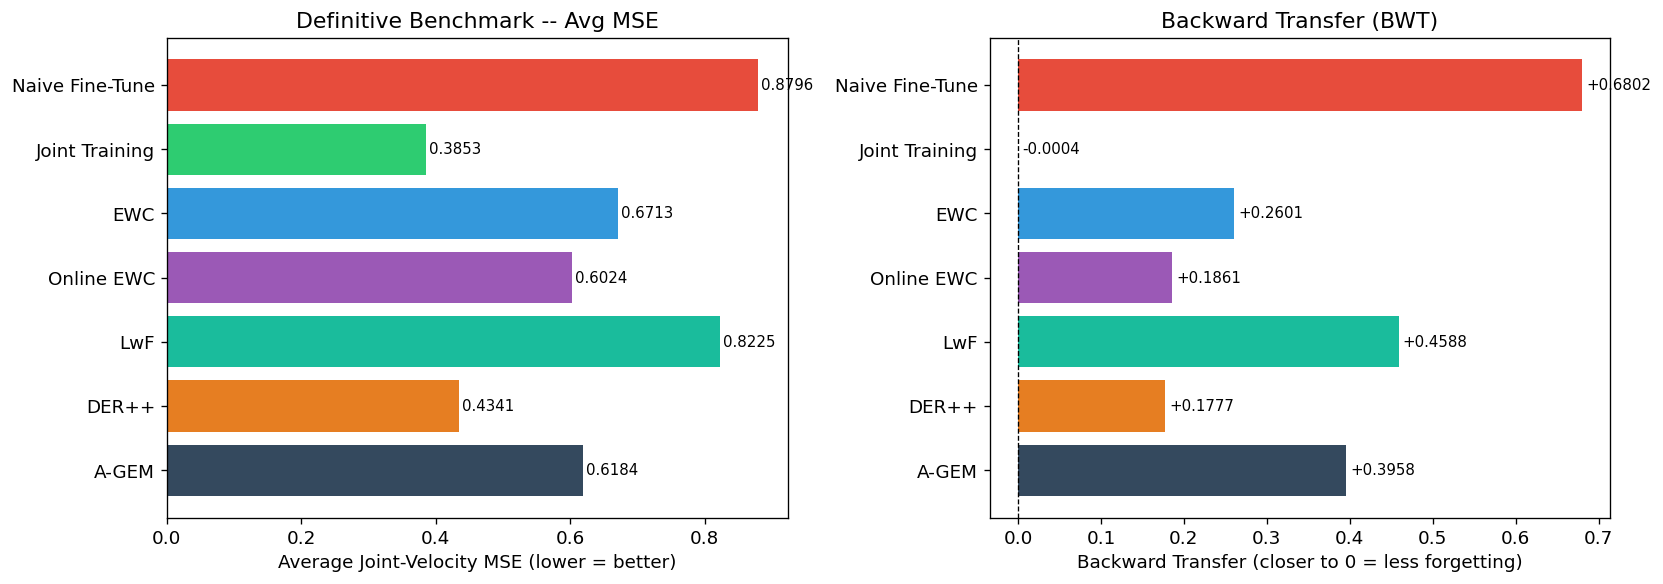

In [16]:
# Comparison Bar Charts
names = list(all_results.keys())
mses  = [all_results[n]['metrics'].average_accuracy for n in names]
bwts  = [all_results[n]['metrics'].backward_transfer for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

ax = axes[0]
bars = ax.barh(names, mses, color=colors[:len(names)])
ax.set_xlabel('Average Joint-Velocity MSE (lower = better)')
ax.set_title('Definitive Benchmark -- Avg MSE')
ax.invert_yaxis()
for bar, v in zip(bars, mses):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)

ax = axes[1]
bars = ax.barh(names, bwts, color=colors[:len(names)])
ax.set_xlabel('Backward Transfer (closer to 0 = less forgetting)')
ax.set_title('Backward Transfer (BWT)')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.invert_yaxis()
for bar, v in zip(bars, bwts):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:+.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

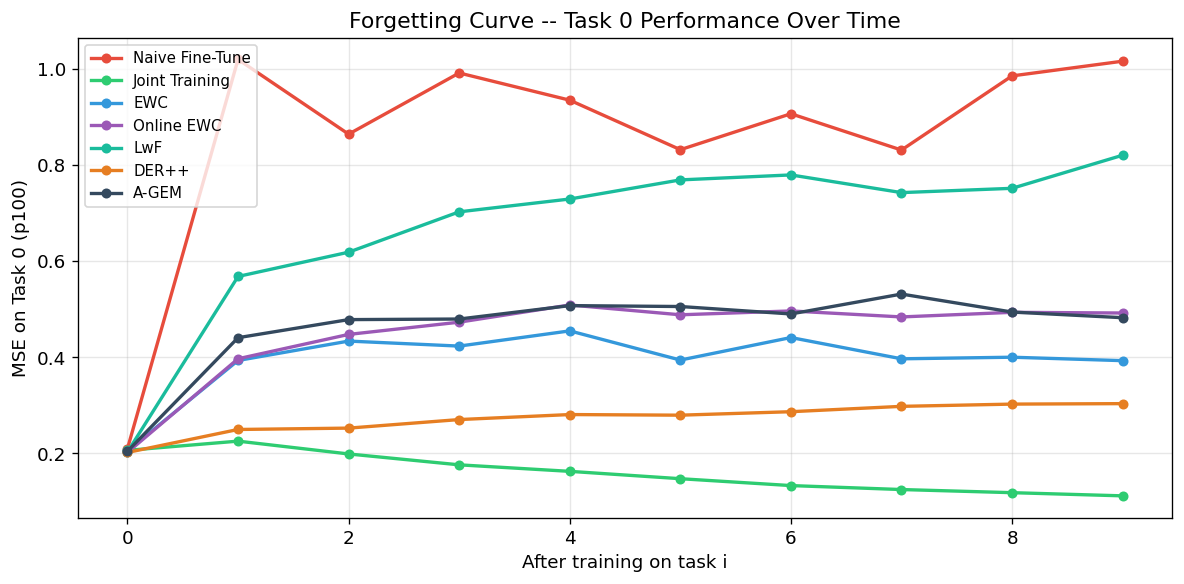

In [17]:
# Forgetting Curve (Task 0)
fig, ax = plt.subplots(figsize=(10, 5))
colors_fc = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']
for idx, (name, res) in enumerate(all_results.items()):
    mat = res['metrics'].accuracy_matrix
    task0 = [mat[i][0] if len(mat[i]) > 0 else np.nan for i in range(len(mat))]
    ax.plot(range(len(task0)), task0, 'o-', label=name, color=colors_fc[idx % len(colors_fc)], linewidth=2, markersize=5)
ax.set_xlabel('After training on task i')
ax.set_ylabel('MSE on Task 0 (p100)')
ax.set_title('Forgetting Curve -- Task 0 Performance Over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/forgetting_curve.png', dpi=150, bbox_inches='tight')
plt.show()

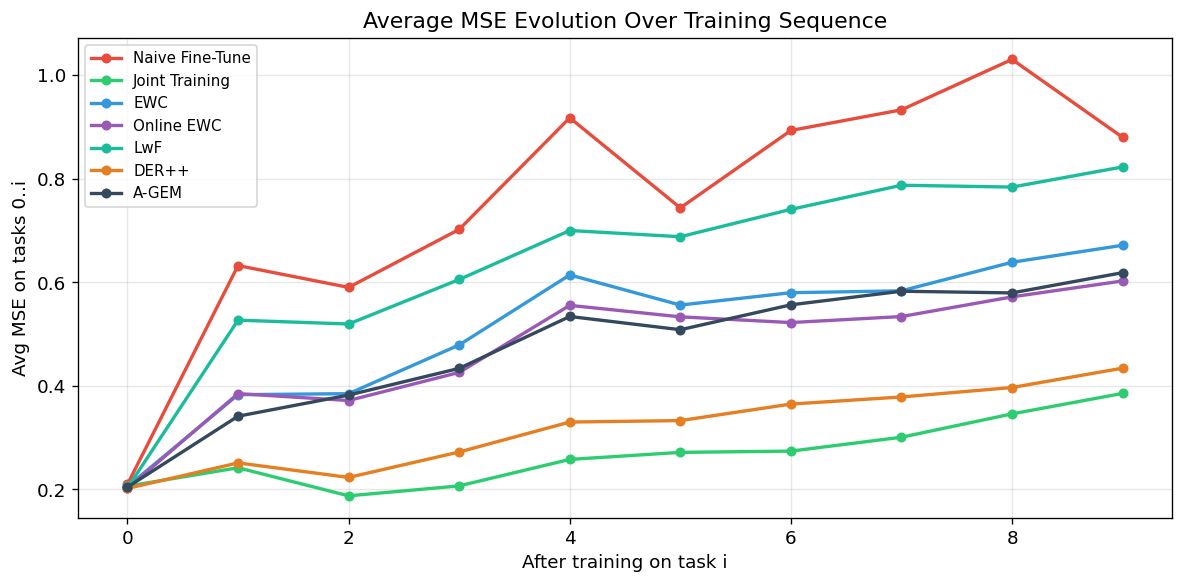

In [18]:
# Average MSE Evolution
fig, ax = plt.subplots(figsize=(10, 5))
for idx, (name, res) in enumerate(all_results.items()):
    mat = res['metrics'].accuracy_matrix
    avg_per_step = [np.mean(mat[i][:i+1]) for i in range(len(mat))]
    ax.plot(range(len(avg_per_step)), avg_per_step, 'o-', label=name,
            color=colors_fc[idx % len(colors_fc)], linewidth=2, markersize=5)
ax.set_xlabel('After training on task i')
ax.set_ylabel('Avg MSE on tasks 0..i')
ax.set_title('Average MSE Evolution Over Training Sequence')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/avg_mse_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

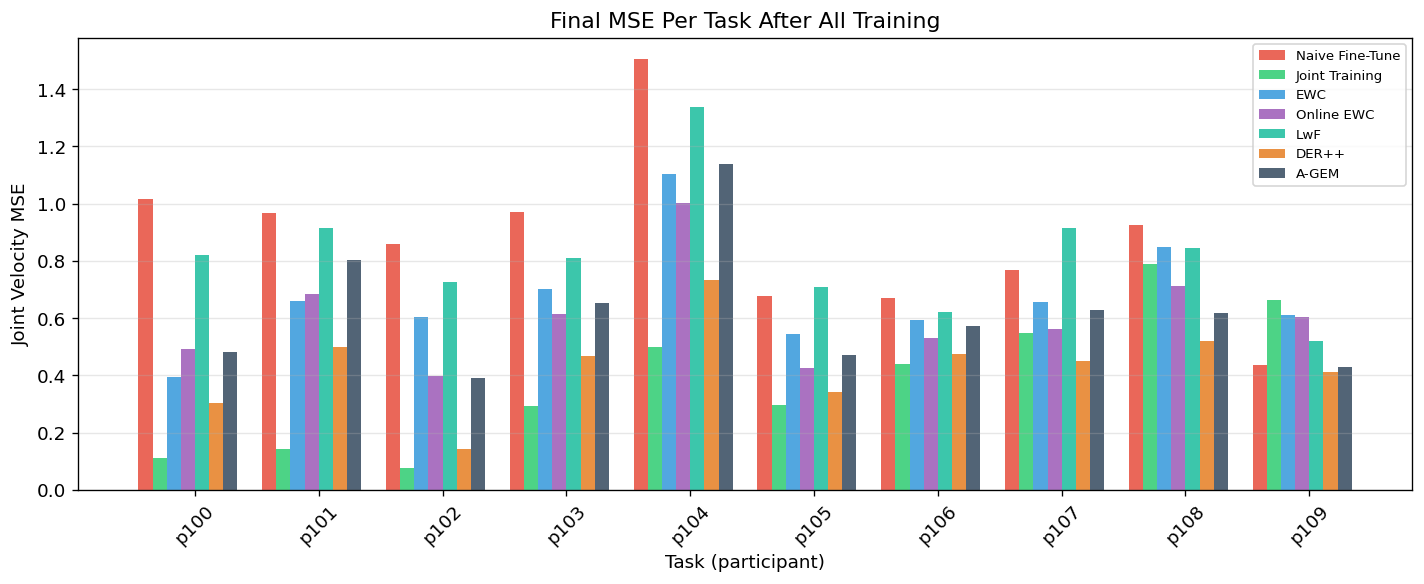

In [19]:
# Per-Task Final MSE
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tasks))
w = 0.8 / max(len(all_results), 1)
for idx, (name, res) in enumerate(all_results.items()):
    raw_mat = res['metrics'].accuracy_matrix
    max_cols = max((len(row) for row in raw_mat), default=0)
    mat = np.array([row + [np.nan]*(max_cols-len(row)) for row in raw_mat])
    last_row = mat[-1][:len(tasks)]
    ax.bar(x[:len(last_row)] + idx*w, last_row, w,
           label=name, color=colors_fc[idx % len(colors_fc)], alpha=0.85)
ax.set_xlabel('Task (participant)')
ax.set_ylabel('Joint Velocity MSE')
ax.set_title('Final MSE Per Task After All Training')
ax.set_xticks(x + w*len(all_results)/2)
ax.set_xticklabels([t.participant_id for t in tasks], rotation=45)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_task_final_mse.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Per-Joint Velocity Analysis

Break down MSE by individual joint (1-6) to identify which joints are hardest to predict and which suffer most from forgetting.

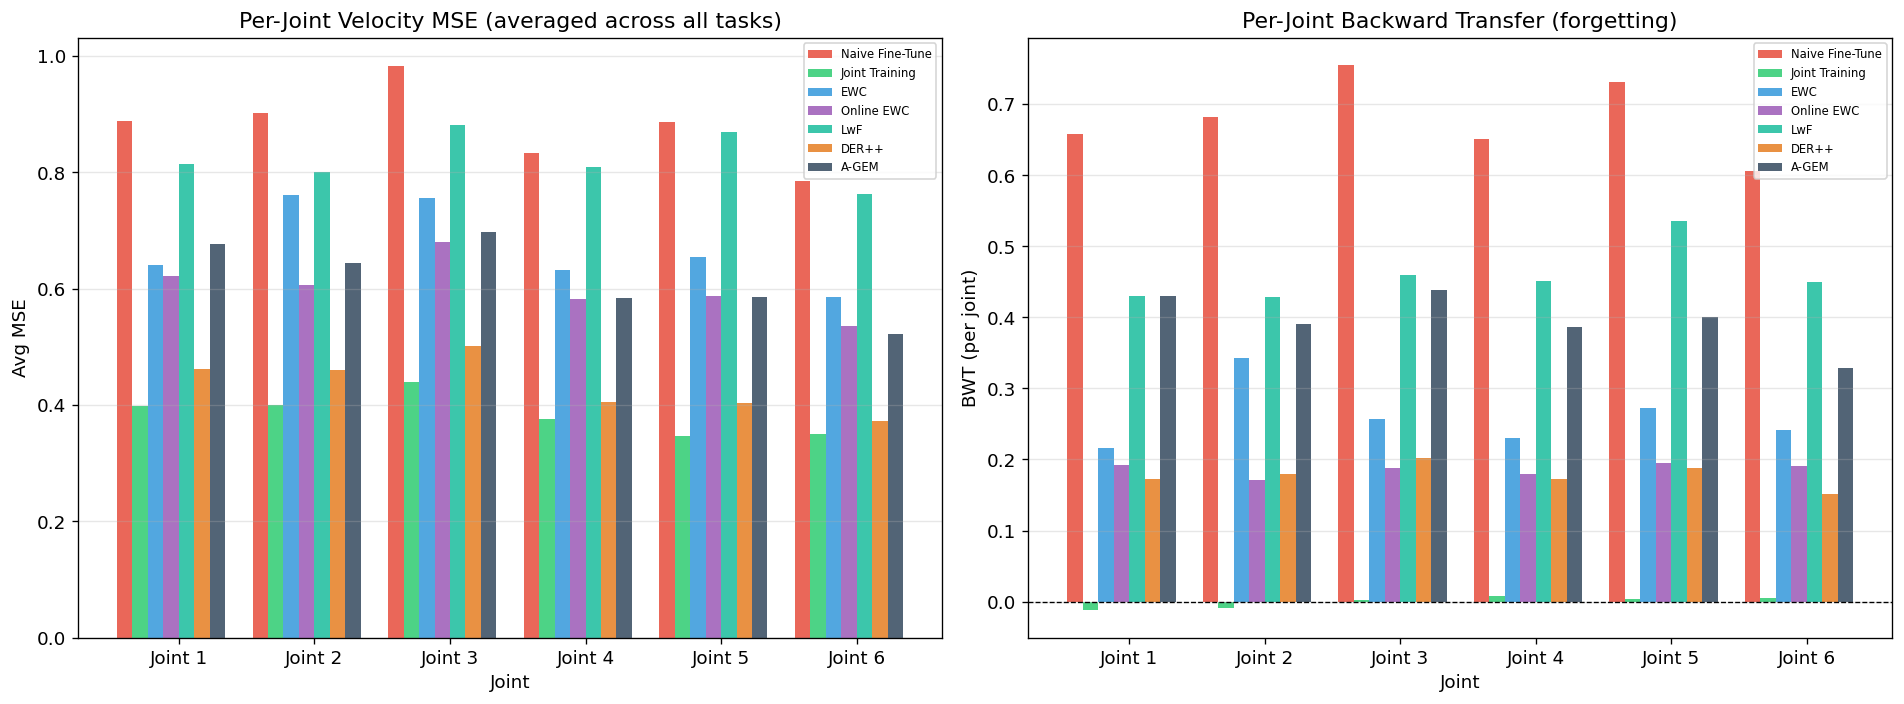

In [20]:
# Per-Joint MSE Breakdown (final row)
joint_names = [f'Joint {i}' for i in range(1, 7)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Per-joint MSE averaged across all tasks ---
ax = axes[0]
x = np.arange(6)
w = 0.8 / max(len(all_results), 1)
for idx, (name, res) in enumerate(all_results.items()):
    per_dim = res['metrics'].per_dim_matrix
    if per_dim and per_dim[-1]:
        # Average per-dim MSE across all tasks (last row)
        last_row_dims = per_dim[-1]  # list of lists: [[j1,j2,...,j6], ...]
        avg_per_joint = np.mean(last_row_dims, axis=0)
        ax.bar(x + idx*w, avg_per_joint, w, label=name,
               color=colors_fc[idx % len(colors_fc)], alpha=0.85)
ax.set_xlabel('Joint')
ax.set_ylabel('Avg MSE')
ax.set_title('Per-Joint Velocity MSE (averaged across all tasks)')
ax.set_xticks(x + w*len(all_results)/2)
ax.set_xticklabels(joint_names)
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# --- Per-joint forgetting (BWT per joint) ---
ax = axes[1]
for idx, (name, res) in enumerate(all_results.items()):
    per_dim = res['metrics'].per_dim_matrix
    T = len(per_dim)
    if T >= 2 and per_dim[-1] and per_dim[0]:
        bwt_per_joint = []
        for j_idx in range(6):
            bwt_j = 0.0
            cnt = 0
            for task_j in range(T - 1):
                if task_j < len(per_dim[T-1]) and task_j < len(per_dim[task_j]):
                    final_j = per_dim[T-1][task_j][j_idx]
                    diag_j = per_dim[task_j][task_j][j_idx]
                    bwt_j += final_j - diag_j
                    cnt += 1
            bwt_per_joint.append(bwt_j / cnt if cnt > 0 else 0)
        ax.bar(x + idx*w, bwt_per_joint, w, label=name,
               color=colors_fc[idx % len(colors_fc)], alpha=0.85)
ax.set_xlabel('Joint')
ax.set_ylabel('BWT (per joint)')
ax.set_title('Per-Joint Backward Transfer (forgetting)')
ax.set_xticks(x + w*len(all_results)/2)
ax.set_xticklabels(joint_names)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_joint_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Per-Joint summary table
print('='*80)
print('PER-JOINT VELOCITY MSE (averaged across all 10 tasks, after final training)')
print('='*80)
header = f'{"Strategy":20s}' + ''.join(f'  Joint_{i:d}' for i in range(1,7)) + '  | Total'
print(header)
print('-'*len(header))
for name, res in all_results.items():
    per_dim = res['metrics'].per_dim_matrix
    if per_dim and per_dim[-1]:
        avg_per_joint = np.mean(per_dim[-1], axis=0)
        vals = ''.join(f'  {v:7.4f}' for v in avg_per_joint)
        total = np.mean(avg_per_joint)
        print(f'{name:20s}{vals}  | {total:.4f}')

print('\n' + '='*80)
print('PER-JOINT BACKWARD TRANSFER (forgetting per joint)')
print('='*80)
print(header)
print('-'*len(header))
for name, res in all_results.items():
    per_dim = res['metrics'].per_dim_matrix
    T = len(per_dim)
    if T >= 2:
        bwt_per_joint = []
        for j_idx in range(6):
            bwt_j = 0.0; cnt = 0
            for task_j in range(T - 1):
                if task_j < len(per_dim[T-1]) and task_j < len(per_dim[task_j]):
                    bwt_j += per_dim[T-1][task_j][j_idx] - per_dim[task_j][task_j][j_idx]
                    cnt += 1
            bwt_per_joint.append(bwt_j / cnt if cnt > 0 else 0)
        vals = ''.join(f'  {v:+7.4f}' for v in bwt_per_joint)
        total = np.mean(bwt_per_joint)
        print(f'{name:20s}{vals}  | {total:+.4f}')

# Identify hardest/easiest joints
print('\n--- Joint difficulty ranking (by DER++ MSE, best strategy) ---')
per_dim = all_results.get('DER++', list(all_results.values())[-1])['metrics'].per_dim_matrix
if per_dim and per_dim[-1]:
    avg = np.mean(per_dim[-1], axis=0)
    ranking = np.argsort(avg)[::-1]
    for rank, j in enumerate(ranking):
        print(f'  {rank+1}. Joint {j+1}: MSE={avg[j]:.4f}')

PER-JOINT VELOCITY MSE (averaged across all 10 tasks, after final training)
Strategy              Joint_1  Joint_2  Joint_3  Joint_4  Joint_5  Joint_6  | Total
-----------------------------------------------------------------------------------
Naive Fine-Tune        0.8889   0.9027   0.9823   0.8328   0.8859   0.7850  | 0.8796
Joint Training         0.3990   0.3995   0.4402   0.3766   0.3466   0.3501  | 0.3853
EWC                    0.6402   0.7607   0.7554   0.6312   0.6545   0.5857  | 0.6713
Online EWC             0.6222   0.6070   0.6798   0.5818   0.5881   0.5356  | 0.6024
LwF                    0.8134   0.8000   0.8818   0.8087   0.8690   0.7620  | 0.8225
DER++                  0.4616   0.4597   0.5019   0.4055   0.4034   0.3724  | 0.4341
A-GEM                  0.6771   0.6436   0.6980   0.5846   0.5851   0.5223  | 0.6184

PER-JOINT BACKWARD TRANSFER (forgetting per joint)
Strategy              Joint_1  Joint_2  Joint_3  Joint_4  Joint_5  Joint_6  | Total
-------------------------

In [22]:
# Save comprehensive results
comparison = {}
for name, res in all_results.items():
    comparison[name] = {
        'avg_mse': res['metrics'].average_accuracy,
        'bwt': res['metrics'].backward_transfer,
        'fwt': res['metrics'].forward_transfer,
        'time_s': round(res['time'], 1),
        'accuracy_matrix': res['metrics'].accuracy_matrix,
        'per_dim_matrix': res['metrics'].per_dim_matrix,
    }
with open(f'{RESULTS_DIR}/full_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)

norm_stats = {
    'obs_mean': obs_mean.tolist(), 'obs_std': obs_std.tolist(),
    'act_mean': act_mean.tolist(), 'act_std': act_std.tolist(),
}
with open(f'{RESULTS_DIR}/normalization_stats.json', 'w') as f:
    json.dump(norm_stats, f, indent=2)

print('All results saved to:', RESULTS_DIR)
for f_name in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f_name))
    print(f'  {f_name:45s} {size/1024:.1f} KB')

All results saved to: /home/g0amer/Desktop/thesis/phd_project/thesis_project/experiments/exp03_definitive_benchmark
  agem_results.json                             21.1 KB
  avg_mse_evolution.png                         135.5 KB
  comparison_bars.png                           82.8 KB
  comparison_table.csv                          0.3 KB
  config.json                                   0.9 KB
  derpp_results.json                            21.1 KB
  ewc_results.json                              21.1 KB
  forgetting_curve.png                          120.7 KB
  full_comparison.json                          159.4 KB
  joint_training_results.json                   21.2 KB
  lwf_results.json                              21.0 KB
  naive_finetune_results.json                   21.0 KB
  normalization_stats.json                      1.0 KB
  online_ewc_results.json                       21.0 KB
  per_joint_analysis.png                        70.8 KB
  per_task_final_mse.png                    

---
## Summary

### Final Rankings (Experiment 3 -- Definitive Benchmark)

| Rank | Strategy | Avg MSE | BWT | FWT | Time |
|------|----------|---------|-----|-----|------|
| 1 | Joint Training | 0.3853 | -0.0004 | +0.6510 | 7814.4s |
| 2 | **DER++ (buf=10K)** | **0.4341** | **+0.1777** | **+0.6463** | **153.1s** |
| 3 | Online EWC (γ=0.99) | 0.6024 | +0.1861 | +0.5178 | 113.8s |
| 4 | A-GEM (new) | 0.6184 | +0.3958 | +0.7934 | 130.0s |
| 5 | EWC (λ=10K) | 0.6713 | +0.2601 | +0.5524 | 179.0s |
| 6 | LwF | 0.8225 | +0.4588 | +0.5320 | 101.0s |
| 7 | Naive Fine-Tune | 0.8796 | +0.6802 | +0.9602 | 92.4s |

### Improvement vs Experiment 01 (tuned HPs + outlier fix)

| Strategy | Exp01 MSE | Exp03 MSE | Improvement |
|----------|-----------|-----------|-------------|
| Joint Training | 0.412 | 0.385 | -6.6% |
| DER++ | 0.480 | 0.434 | -9.6% |
| Online EWC | 0.681 | 0.602 | -11.6% |
| EWC | 0.713 | 0.671 | -5.9% |
| LwF | 0.827 | 0.823 | -0.5% |
| Naive | 0.939 | 0.880 | -6.3% |

> **Best improvement:** Online EWC (-11.6%) thanks to γ tuning (0.95→0.99).
> **DER++** improved by 9.6% with doubled buffer (5K→10K).

### Per-Joint Findings

| Joint | Role | DER++ MSE | DER++ BWT | Difficulty Rank |
|-------|------|-----------|-----------|-----------------|
| Joint 3 | Elbow | 0.5019 | +0.2018 | 1 (hardest) |
| Joint 1 | Shoulder | 0.4616 | +0.1721 | 2 |
| Joint 2 | Shoulder | 0.4597 | +0.1798 | 3 |
| Joint 4 | Wrist | 0.4055 | +0.1727 | 4 |
| Joint 5 | Wrist | 0.4034 | +0.1879 | 5 |
| Joint 6 | Wrist | 0.3724 | +0.1521 | 6 (easiest) |

- **Hardest joint:** Joint 3 (elbow) -- consistently highest MSE across all strategies
- **Easiest joint:** Joint 6 (wrist rotation) -- lowest MSE and least forgotten
- **Most forgotten joint:** Joint 3 (elbow) -- highest BWT across Naive, DER++, A-GEM

### Key Conclusions

1. **DER++ remains the best incremental strategy** (MSE=0.434), only 12.7% behind Joint Training upper bound
2. **A-GEM (new) placed 4th** (MSE=0.618) -- gradient projection struggles more than replay on this task; BWT is worse than Online EWC despite memory usage
3. **Online EWC benefits most from HP tuning** (-11.6%), confirming that γ=0.99 provides stronger memory consolidation
4. **Elbow joint (J3) is the bottleneck** -- highest difficulty and highest forgetting; may benefit from dedicated protection or separate modeling
5. **SI removal justified** -- replaced by A-GEM which, while not top-performing, at least functions correctly on this task